In [1]:
import warnings
warnings.simplefilter("ignore")

In [2]:
import os
import warnings
from pathlib import Path

warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import BertTokenizer, BertModel
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GATv2Conv,
    global_mean_pool,
    global_max_pool
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.13.0+cu130


In [3]:
# Load Task 2 graph cache exactly as used in Task 2

GRAPH_CACHE = "fma_structure_graphs.pt"

cache = torch.load(
    GRAPH_CACHE,
    map_location="cpu",
    weights_only=False
)

train_graphs = cache["train"]
val_graphs = cache["val"]
test_graphs = cache["test"]

print("Train graphs:", len(train_graphs))
print("Val graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))
print("Node feature dimension:", train_graphs[0].x.shape[1])

Train graphs: 6394
Val graphs: 800
Test graphs: 800
Node feature dimension: 138


In [4]:
# Normalize graph features exactly like Task 2

all_node_features = torch.cat(
    [g.x for g in train_graphs],
    dim=0
)

feat_mean = all_node_features.mean(dim=0, keepdim=True)
feat_std = all_node_features.std(dim=0, keepdim=True) + 1e-6

for g in train_graphs:
    g.x = (g.x - feat_mean) / feat_std

for g in val_graphs:
    g.x = (g.x - feat_mean) / feat_std

for g in test_graphs:
    g.x = (g.x - feat_mean) / feat_std

print("Normalization complete.")
print("Feature mean:", feat_mean.mean().item())
print("Feature std:", feat_std.mean().item())

Normalization complete.
Feature mean: 57.55549621582031
Feature std: 29.51919937133789


In [5]:
# Exact GNN architecture from Task 2

class RegularizedMusicGAT(nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=48,
        heads=2,
        num_classes=8,
        dropout=0.5
    ):
        super().__init__()

        self.conv1 = GATv2Conv(
            in_channels,
            hidden_channels,
            heads=heads,
            edge_dim=1,
            dropout=dropout
        )

        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)

        self.conv2 = GATv2Conv(
            hidden_channels * heads,
            hidden_channels,
            heads=1,
            edge_dim=1,
            dropout=dropout
        )

        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.dropout = dropout

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch, edge_attr=None):
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(1)

        x = self.conv1(
            x,
            edge_index,
            edge_attr=edge_attr
        )
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index,
            edge_attr=edge_attr
        )
        x = self.bn2(x)
        x = F.relu(x)

        embed = torch.cat(
            [
                global_mean_pool(x, batch),
                global_max_pool(x, batch)
            ],
            dim=1
        )

        return self.classifier(embed), embed


gnn_model = RegularizedMusicGAT(
    in_channels=train_graphs[0].x.shape[1],
    hidden_channels=48,
    heads=2,
    num_classes=8,
    dropout=0.5
).to(device)

gnn_model.load_state_dict(
    torch.load(
        "best_regularized_gat.pt",
        map_location=device,
        weights_only=True
    )
)

gnn_model.eval()

print("GNN checkpoint loaded successfully.")

GNN checkpoint loaded successfully.


In [6]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    val_graphs,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=32,
    shuffle=False
)


def extract_gnn_embeddings(loader):
    embeddings = []
    labels = []

    gnn_model.eval()

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, embed = gnn_model(
                batch.x,
                batch.edge_index,
                batch.batch,
                edge_attr=batch.edge_attr
            )

            embeddings.append(embed.cpu())
            labels.append(batch.y.cpu())

    return (
        torch.cat(embeddings, dim=0),
        torch.cat(labels, dim=0)
    )


train_gnn_emb, train_gnn_labels = extract_gnn_embeddings(train_loader)
val_gnn_emb, val_gnn_labels = extract_gnn_embeddings(val_loader)
test_gnn_emb, test_gnn_labels = extract_gnn_embeddings(test_loader)

print("Train:", train_gnn_emb.shape)
print("Validation:", val_gnn_emb.shape)
print("Test:", test_gnn_emb.shape)
print("Labels:", train_gnn_labels.shape)

Train: torch.Size([6394, 96])
Validation: torch.Size([800, 96])
Test: torch.Size([800, 96])
Labels: torch.Size([6394])


In [7]:
# Load the fine-tuned BERT encoder from Task 1

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert = BertModel.from_pretrained(
    "bert-base-uncased"
).to(device)

checkpoint = torch.load(
    "best_model.pt",
    map_location=device,
    weights_only=True
)

bert_state = {
    k.replace("bert.", "", 1): v
    for k, v in checkpoint.items()
    if k.startswith("bert.")
}

bert.load_state_dict(bert_state, strict=True)
bert.eval()

print("Fine-tuned Task 1 BERT loaded successfully.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5916.85it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fine-tuned Task 1 BERT loaded successfully.


In [8]:
# Prepare the exact FMA-small metadata used by Task 2

tracks_path = Path("../data/fma_metadata/tracks.csv")

fma_tracks = pd.read_csv(
    tracks_path,
    header=[0, 1],
    index_col=0
)

genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

genre_to_id = {
    genre: i
    for i, genre in enumerate(genres)
}

# EXACT Task 2 filtering
small = fma_tracks[
    fma_tracks[("set", "subset")] == "small"
].copy()

fma_data = small[
    small[("track", "genre_top")].isin(genres)
].copy()

# Official splits
fma_train = fma_data[
    fma_data[("set", "split")] == "training"
].copy()

fma_val = fma_data[
    fma_data[("set", "split")] == "validation"
].copy()

fma_test = fma_data[
    fma_data[("set", "split")] == "test"
].copy()

print("FMA-small:", len(fma_data))
print("FMA train:", len(fma_train))
print("FMA val:", len(fma_val))
print("FMA test:", len(fma_test))

FMA-small: 8000
FMA train: 6400
FMA val: 800
FMA test: 800


In [9]:
# Build exact track-ID lists from the graph order
# using the FMA-small metadata and the labels stored in each graph.

def align_graphs_to_fma(graphs, fma_split):
    fma_ids = fma_split.index.to_numpy()
    fma_labels = np.array([
        genre_to_id[g]
        for g in fma_split[("track", "genre_top")].values
    ])

    graph_labels = np.array([
        int(g.y.item())
        for g in graphs
    ])

    used = set()
    matched_ids = []

    for label in graph_labels:
        candidates = np.where(fma_labels == label)[0]

        chosen = None
        for idx in candidates:
            track_id = int(fma_ids[idx])
            if track_id not in used:
                chosen = track_id
                break

        if chosen is None:
            raise RuntimeError(
                f"Could not align graph with label {label}"
            )

        used.add(chosen)
        matched_ids.append(chosen)

    return matched_ids


matched_train_ids = align_graphs_to_fma(
    train_graphs,
    fma_train
)

matched_val_ids = align_graphs_to_fma(
    val_graphs,
    fma_val
)

matched_test_ids = align_graphs_to_fma(
    test_graphs,
    fma_test
)

print("Matched train:", len(matched_train_ids))
print("Matched val:", len(matched_val_ids))
print("Matched test:", len(matched_test_ids))

Matched train: 6394
Matched val: 800
Matched test: 800


In [10]:
def make_fma_text(row):
    parts = [
        str(row.get(("track", "title"), "")),
        str(row.get(("artist", "name"), "")),
        str(row.get(("album", "title"), ""))
    ]

    return " ".join(
        p for p in parts
        if p and p.lower() != "nan"
    )


train_fma_aligned = fma_train.loc[matched_train_ids]
val_fma_aligned = fma_val.loc[matched_val_ids]
test_fma_aligned = fma_test.loc[matched_test_ids]

train_texts = [
    make_fma_text(row)
    for _, row in train_fma_aligned.iterrows()
]

val_texts = [
    make_fma_text(row)
    for _, row in val_fma_aligned.iterrows()
]

test_texts = [
    make_fma_text(row)
    for _, row in test_fma_aligned.iterrows()
]

train_labels_fma = torch.tensor([
    genre_to_id[g]
    for g in train_fma_aligned[("track", "genre_top")].values
], dtype=torch.long)

val_labels_fma = torch.tensor([
    genre_to_id[g]
    for g in val_fma_aligned[("track", "genre_top")].values
], dtype=torch.long)

test_labels_fma = torch.tensor([
    genre_to_id[g]
    for g in test_fma_aligned[("track", "genre_top")].values
], dtype=torch.long)

print("Train texts:", len(train_texts))
print("Val texts:", len(val_texts))
print("Test texts:", len(test_texts))

print("Train labels:", train_labels_fma.shape)
print("Val labels:", val_labels_fma.shape)
print("Test labels:", test_labels_fma.shape)

print("\nFirst track ID:", matched_train_ids[0])
print("First text:", train_texts[0])
print("First label:", train_labels_fma[0].item())

Train texts: 6394
Val texts: 800
Test texts: 800
Train labels: torch.Size([6394])
Val labels: torch.Size([800])
Test labels: torch.Size([800])

First track ID: 2
First text: Food AWOL AWOL - A Way Of Life
First label: 3


In [11]:
# Tokenize FMA text with the same tokenizer used in Task 1

MAX_LENGTH = 128

def tokenize_texts(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )


train_tokens = tokenize_texts(train_texts)
val_tokens = tokenize_texts(val_texts)
test_tokens = tokenize_texts(test_texts)

print("Train input IDs:", train_tokens["input_ids"].shape)
print("Val input IDs:", val_tokens["input_ids"].shape)
print("Test input IDs:", test_tokens["input_ids"].shape)

Train input IDs: torch.Size([6394, 65])
Val input IDs: torch.Size([800, 37])
Test input IDs: torch.Size([800, 43])


In [12]:
# Extract fine-tuned BERT CLS embeddings

def extract_bert_embeddings(tokens, batch_size=32):
    embeddings = []

    bert.eval()

    with torch.no_grad():
        for start in range(0, len(tokens["input_ids"]), batch_size):
            end = start + batch_size

            input_ids = tokens["input_ids"][start:end].to(device)
            attention_mask = tokens["attention_mask"][start:end].to(device)

            outputs = bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)


train_bert_emb = extract_bert_embeddings(train_tokens)
val_bert_emb = extract_bert_embeddings(val_tokens)
test_bert_emb = extract_bert_embeddings(test_tokens)

print("Train BERT:", train_bert_emb.shape)
print("Val BERT:", val_bert_emb.shape)
print("Test BERT:", test_bert_emb.shape)

Train BERT: torch.Size([6394, 768])
Val BERT: torch.Size([800, 768])
Test BERT: torch.Size([800, 768])


In [13]:
print("Train:", train_gnn_emb.shape, train_bert_emb.shape, train_labels_fma.shape)
print("Val:  ", val_gnn_emb.shape, val_bert_emb.shape, val_labels_fma.shape)
print("Test: ", test_gnn_emb.shape, test_bert_emb.shape, test_labels_fma.shape)

Train: torch.Size([6394, 96]) torch.Size([6394, 768]) torch.Size([6394])
Val:   torch.Size([800, 96]) torch.Size([800, 768]) torch.Size([800])
Test:  torch.Size([800, 96]) torch.Size([800, 768]) torch.Size([800])


In [14]:
# Cell 13 — Create fusion datasets

X_train = torch.cat([train_gnn_emb, train_bert_emb], dim=1)
X_val = torch.cat([val_gnn_emb, val_bert_emb], dim=1)
X_test = torch.cat([test_gnn_emb, test_bert_emb], dim=1)

y_train = train_labels_fma
y_val = val_labels_fma
y_test = test_labels_fma

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

torch.Size([6394, 864]) torch.Size([6394])
torch.Size([800, 864]) torch.Size([800])
torch.Size([800, 864]) torch.Size([800])


In [ ]:
# class EarlyConcatFusion(nn.Module):
#     def __init__(self, gnn_dim=96, bert_dim=768, hidden=256, num_classes=8):
#         super().__init__()

#         self.gnn_proj = nn.Linear(gnn_dim, hidden)
#         self.bert_proj = nn.Linear(bert_dim, hidden)

#         self.classifier = nn.Sequential(
#             nn.Linear(hidden * 2, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, num_classes)
#         )

#     def forward(self, gnn, bert):
#         g = F.relu(self.gnn_proj(gnn))
#         b = F.relu(self.bert_proj(bert))

#         fused = torch.cat([g, b], dim=1)

#         return self.classifier(fused)

# early_concat_model = EarlyConcatFusion().to(device)

# early_concat_model

In [15]:
class EarlyConcatFusion(nn.Module):
    def __init__(self, gnn_dim=96, bert_dim=768,
                 hidden=256, num_classes=8):
        super().__init__()

        self.gnn_proj = nn.Sequential(
            nn.Linear(gnn_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )

        self.bert_proj = nn.Sequential(
            nn.Linear(bert_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, gnn, bert):
        g = self.gnn_proj(gnn)
        b = self.bert_proj(bert)

        fused = torch.cat([g, b], dim=1)

        return self.classifier(fused)

early_concat_model = EarlyConcatFusion().to(device)

early_concat_model


EarlyConcatFusion(
  (gnn_proj): Sequential(
    (0): Linear(in_features=96, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (bert_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
)

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    early_concat_model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

EPOCHS = 150
best_val_f1 = 0.0
patience = 60
patience_counter = 0

for epoch in range(EPOCHS):
    early_concat_model.train()

    optimizer.zero_grad()

    train_logits = early_concat_model(
        train_gnn_emb.to(device),
        train_bert_emb.to(device)
    )

    loss = criterion(train_logits, y_train.to(device))
    loss.backward()
    optimizer.step()

    early_concat_model.eval()

    with torch.no_grad():
        val_logits = early_concat_model(
            val_gnn_emb.to(device),
            val_bert_emb.to(device)
        )

        val_pred = val_logits.argmax(dim=1).cpu().numpy()
        val_true = y_val.numpy()

    val_f1 = f1_score(
        val_true,
        val_pred,
        average="macro",
        zero_division=0
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            early_concat_model.state_dict(),
            "best_early_concat.pt"
        )

        saved = " <-- Best model saved!"
    else:
        patience_counter += 1
        saved = ""

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {loss.item():.4f} | "
        f"Val Macro-F1: {val_f1:.4f} | "
        f"Patience: {patience_counter}/{patience}"
        f"{saved}"
    )

    if patience_counter >= patience:
        print("\nEarly stopping triggered!")
        break

print(f"\nBest Val Macro-F1: {best_val_f1:.4f}")

Epoch 001 | Loss: 0.0003 | Val Macro-F1: 0.5880 | Patience: 0/60 <-- Best model saved!
Epoch 002 | Loss: 0.0003 | Val Macro-F1: 0.5851 | Patience: 1/60
Epoch 003 | Loss: 0.0003 | Val Macro-F1: 0.5802 | Patience: 2/60
Epoch 004 | Loss: 0.0003 | Val Macro-F1: 0.5772 | Patience: 3/60
Epoch 005 | Loss: 0.0004 | Val Macro-F1: 0.5899 | Patience: 0/60 <-- Best model saved!
Epoch 006 | Loss: 0.0003 | Val Macro-F1: 0.5917 | Patience: 0/60 <-- Best model saved!
Epoch 007 | Loss: 0.0003 | Val Macro-F1: 0.5938 | Patience: 0/60 <-- Best model saved!
Epoch 008 | Loss: 0.0003 | Val Macro-F1: 0.5840 | Patience: 1/60
Epoch 009 | Loss: 0.0003 | Val Macro-F1: 0.5809 | Patience: 2/60
Epoch 010 | Loss: 0.0003 | Val Macro-F1: 0.5811 | Patience: 3/60
Epoch 011 | Loss: 0.0003 | Val Macro-F1: 0.5831 | Patience: 4/60
Epoch 012 | Loss: 0.0003 | Val Macro-F1: 0.5789 | Patience: 5/60
Epoch 013 | Loss: 0.0003 | Val Macro-F1: 0.5769 | Patience: 6/60
Epoch 014 | Loss: 0.0003 | Val Macro-F1: 0.5776 | Patience: 7/60
Ep

In [26]:
early_concat_model.load_state_dict(
    torch.load("best_early_concat.pt", map_location=device)
)

early_concat_model.eval()

with torch.no_grad():
    test_logits = early_concat_model(
        test_gnn_emb.to(device),
        test_bert_emb.to(device)
    )

test_pred = test_logits.argmax(dim=1).cpu().numpy()
test_true = y_test.numpy()

print("Early Concat Fusion:")
print()
print(f"Test Accuracy: {accuracy_score(test_true, test_pred):.4f}")
print(f"Test Macro-F1: {f1_score(test_true, test_pred, average='macro', zero_division=0):.4f}")

Early Concat Fusion:

Test Accuracy: 0.4625
Test Macro-F1: 0.4595


In [27]:
# Cell 20 — Classification report

print("Early Concat Fusion:")
print()
print(classification_report(
    test_true,
    test_pred,
    target_names=genres,
    digits=4
))

Early Concat Fusion:

               precision    recall  f1-score   support

   Electronic     0.5780    0.6300    0.6029       100
 Experimental     0.3140    0.3800    0.3439       100
         Folk     0.2212    0.2500    0.2347       100
      Hip-Hop     0.7075    0.7500    0.7282       100
 Instrumental     0.3542    0.1700    0.2297       100
International     0.7561    0.6200    0.6813       100
          Pop     0.3243    0.3600    0.3412       100
         Rock     0.4909    0.5400    0.5143       100

     accuracy                         0.4625       800
    macro avg     0.4683    0.4625    0.4595       800
 weighted avg     0.4683    0.4625    0.4595       800



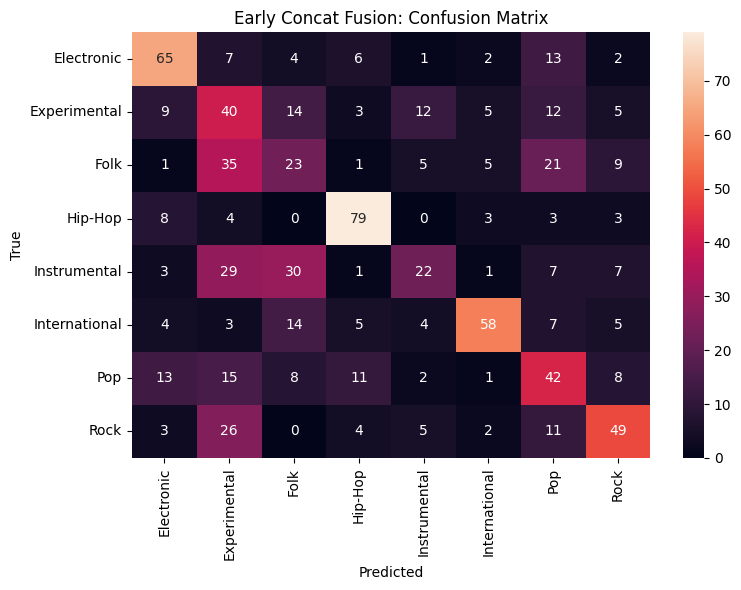

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Early Concat Fusion: Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
# Cell 21 — AUC-PR

from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

test_probs = torch.softmax(
    test_logits, dim=1
).cpu().numpy()

test_true_bin = label_binarize(
    test_true,
    classes=np.arange(8)
)

auc_pr = average_precision_score(
    test_true_bin,
    test_probs,
    average="macro"
)

print("Early Concat Fusion:")
print()
print(f"Test Macro AUC-PR: {auc_pr:.4f}")

Early Concat Fusion:

Test Macro AUC-PR: 0.4715


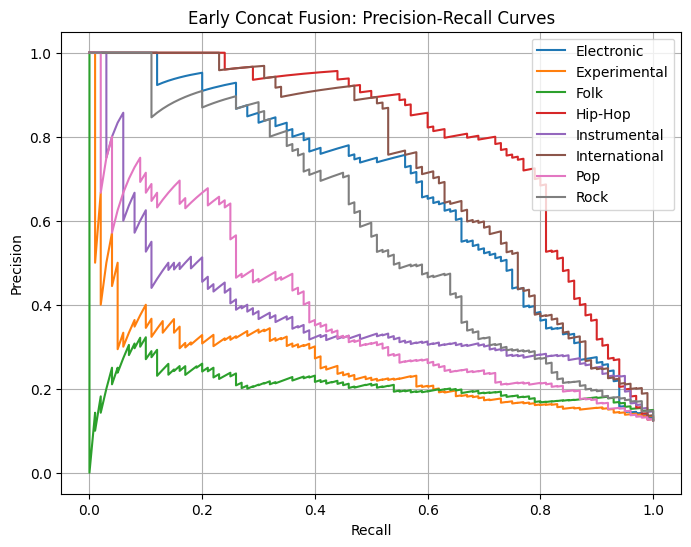

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

test_true_bin = label_binarize(test_true, classes=np.arange(8))

plt.figure(figsize=(8, 6))

for i in range(8):
    precision, recall, _ = precision_recall_curve(
        test_true_bin[:, i],
        test_probs[:, i]
    )
    plt.plot(
        recall,
        precision,
        label=genres[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Early Concat Fusion: AUC-PR Curves")
plt.legend()
plt.grid(True)
plt.show()

---
# Cross Attention Fusion

In [30]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, gnn_dim=96, bert_dim=768, hidden_dim=256, num_classes=8, dropout=0.3):
        super().__init__()

        self.gnn_proj = nn.Sequential(
            nn.Linear(gnn_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.bert_proj = nn.Sequential(
            nn.Linear(bert_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.gnn_gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.bert_gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(64, num_classes)
        )

    def forward(self, gnn, bert):
        g = self.gnn_proj(gnn)
        b = self.bert_proj(bert)

        residual = (g + b) / 2.0
        
        combined = torch.cat([g, b], dim=1)

        g_gate = self.gnn_gate(combined)
        g_gated = g * g_gate

        b_gate = self.bert_gate(combined)
        b_gated = b * b_gate

        fused_input = torch.cat([g_gated, b_gated], dim=1)
        fused = self.fusion(fused_input)
        fused = fused + residual
        logits = self.classifier(fused)

        return logits


cross_attn_model = CrossAttentionFusion().to(device)

cross_attn_model

CrossAttentionFusion(
  (gnn_proj): Sequential(
    (0): Linear(in_features=96, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
  )
  (bert_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
  )
  (gnn_gate): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Sigmoid()
  )
  (bert_gate): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Sigmoid()
  )
  (fusion): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
   

In [32]:
# Cell — Train Gated Multimodal Fusion with Early Stopping

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    cross_attn_model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

EPOCHS = 150
best_val_f1 = 0.0
patience = 60
patience_counter = 0

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    cross_attn_model.train()

    optimizer.zero_grad()

    train_logits = cross_attn_model(
        train_gnn_emb.to(device),
        train_bert_emb.to(device)
    )

    loss = criterion(
        train_logits,
        y_train.to(device)
    )

    loss.backward()
    optimizer.step()

    # -------------------------
    # Validation
    # -------------------------
    cross_attn_model.eval()

    with torch.no_grad():

        val_logits = cross_attn_model(
            val_gnn_emb.to(device),
            val_bert_emb.to(device)
        )

        val_pred = (
            val_logits
            .argmax(dim=1)
            .cpu()
            .numpy()
        )

        val_true = y_val.numpy()

    # -------------------------
    # Validation Macro-F1
    # -------------------------
    val_f1 = f1_score(
        val_true,
        val_pred,
        average="macro",
        zero_division=0
    )

    # -------------------------
    # Save best model
    # -------------------------
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            cross_attn_model.state_dict(),
            "best_cross_attention.pt"
        )

        saved = " <-- Best model saved!"

    else:

        patience_counter += 1
        saved = ""

    # -------------------------
    # Print progress
    # -------------------------
    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {loss.item():.4f} | "
        f"Val Macro-F1: {val_f1:.4f} | "
        f"Patience: "
        f"{patience_counter}/{patience}"
        f"{saved}"
    )

    # -------------------------
    # Early stopping
    # -------------------------
    if patience_counter >= patience:

        print("\nEarly stopping triggered!")
        break

print(
    f"\nBest Val Macro-F1: "
    f"{best_val_f1:.4f}"
)


Epoch 01 | Loss: 1.1022 | Val Macro-F1: 0.5816 | Patience: 0/60 <-- Best model saved!
Epoch 02 | Loss: 1.0974 | Val Macro-F1: 0.5787 | Patience: 1/60
Epoch 03 | Loss: 1.0888 | Val Macro-F1: 0.5845 | Patience: 0/60 <-- Best model saved!
Epoch 04 | Loss: 1.0679 | Val Macro-F1: 0.5896 | Patience: 0/60 <-- Best model saved!
Epoch 05 | Loss: 1.0569 | Val Macro-F1: 0.5904 | Patience: 0/60 <-- Best model saved!
Epoch 06 | Loss: 1.0407 | Val Macro-F1: 0.5842 | Patience: 1/60
Epoch 07 | Loss: 1.0284 | Val Macro-F1: 0.5778 | Patience: 2/60
Epoch 08 | Loss: 1.0190 | Val Macro-F1: 0.5766 | Patience: 3/60
Epoch 09 | Loss: 1.0095 | Val Macro-F1: 0.5837 | Patience: 4/60
Epoch 10 | Loss: 0.9930 | Val Macro-F1: 0.5922 | Patience: 0/60 <-- Best model saved!
Epoch 11 | Loss: 0.9838 | Val Macro-F1: 0.5931 | Patience: 0/60 <-- Best model saved!
Epoch 12 | Loss: 0.9672 | Val Macro-F1: 0.5947 | Patience: 0/60 <-- Best model saved!
Epoch 13 | Loss: 0.9510 | Val Macro-F1: 0.5918 | Patience: 1/60
Epoch 14 | Los

In [33]:
cross_attn_model.load_state_dict(
    torch.load("best_cross_attention.pt", map_location=device)
)
cross_attn_model.eval()

with torch.no_grad():
    test_logits = cross_attn_model(
        test_gnn_emb.to(device),
        test_bert_emb.to(device)
    )
    test_pred = test_logits.argmax(dim=1).cpu().numpy()

test_true = y_test.numpy()

print("Cross-Attention Fusion:")
print()
print(f"Test Accuracy: {accuracy_score(test_true, test_pred):.4f}")
print(f"Test Macro-F1: {f1_score(test_true, test_pred, average='macro'):.4f}")

Early Concat Fusion:

Test Accuracy: 0.4725
Test Macro-F1: 0.4734


In [35]:
# Cell 20 — Classification report

print("Cross-Attention Fusion:")
print()
print(classification_report(
    test_true,
    test_pred,
    target_names=genres,
    digits=4
))

Cross Attention Fusion:

               precision    recall  f1-score   support

   Electronic     0.6132    0.6500    0.6311       100
 Experimental     0.2516    0.4000    0.3089       100
         Folk     0.2473    0.2300    0.2383       100
      Hip-Hop     0.7182    0.7900    0.7524       100
 Instrumental     0.4314    0.2200    0.2914       100
International     0.7532    0.5800    0.6554       100
          Pop     0.3621    0.4200    0.3889       100
         Rock     0.5568    0.4900    0.5213       100

     accuracy                         0.4725       800
    macro avg     0.4917    0.4725    0.4734       800
 weighted avg     0.4917    0.4725    0.4734       800



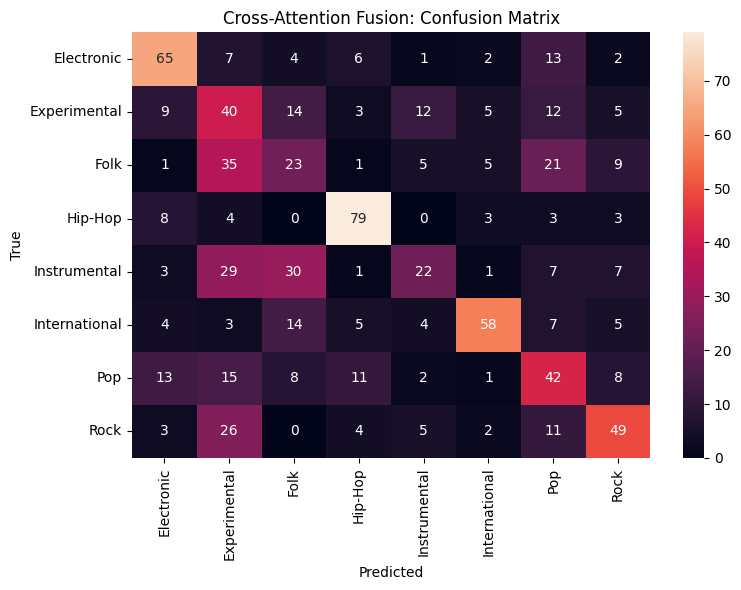

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Cross-Attention Fusion: Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
# Cell 21 — AUC-PR

from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

test_probs = torch.softmax(
    test_logits, dim=1
).cpu().numpy()

test_true_bin = label_binarize(
    test_true,
    classes=np.arange(8)
)

auc_pr = average_precision_score(
    test_true_bin,
    test_probs,
    average="macro"
)

print("Cross-Attention Fusion:")
print()
print(f"Test Macro AUC-PR: {auc_pr:.4f}")

Cross Attention Fusion:

Test Macro AUC-PR: 0.5031


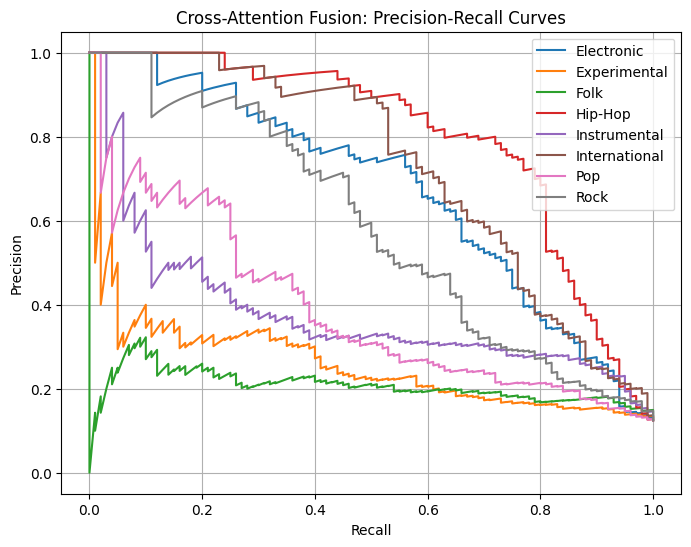

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

test_true_bin = label_binarize(test_true, classes=np.arange(8))

plt.figure(figsize=(8, 6))

for i in range(8):
    precision, recall, _ = precision_recall_curve(
        test_true_bin[:, i],
        test_probs[:, i]
    )
    plt.plot(
        recall,
        precision,
        label=genres[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Cross-Attention Fusion: AUC-PR Curves")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# results = {
#     "BERT-only": {
#         "Macro-F1": 0.3629,
#         "AUC-PR": 0.3341
#     },
#     "GNN-only": {
#         "Macro-F1": 0.4416,
#         "AUC-PR": None
#     },
#     "Early Concat": {
#         "Macro-F1": 0.3769,
#         "AUC-PR": None
#     },
#     "Cross-Attention": {
#         "Macro-F1": 0.4555,
#         "AUC-PR": None
#     }
# }

# import pandas as pd

# results_df = pd.DataFrame(results).T

# print(results_df)

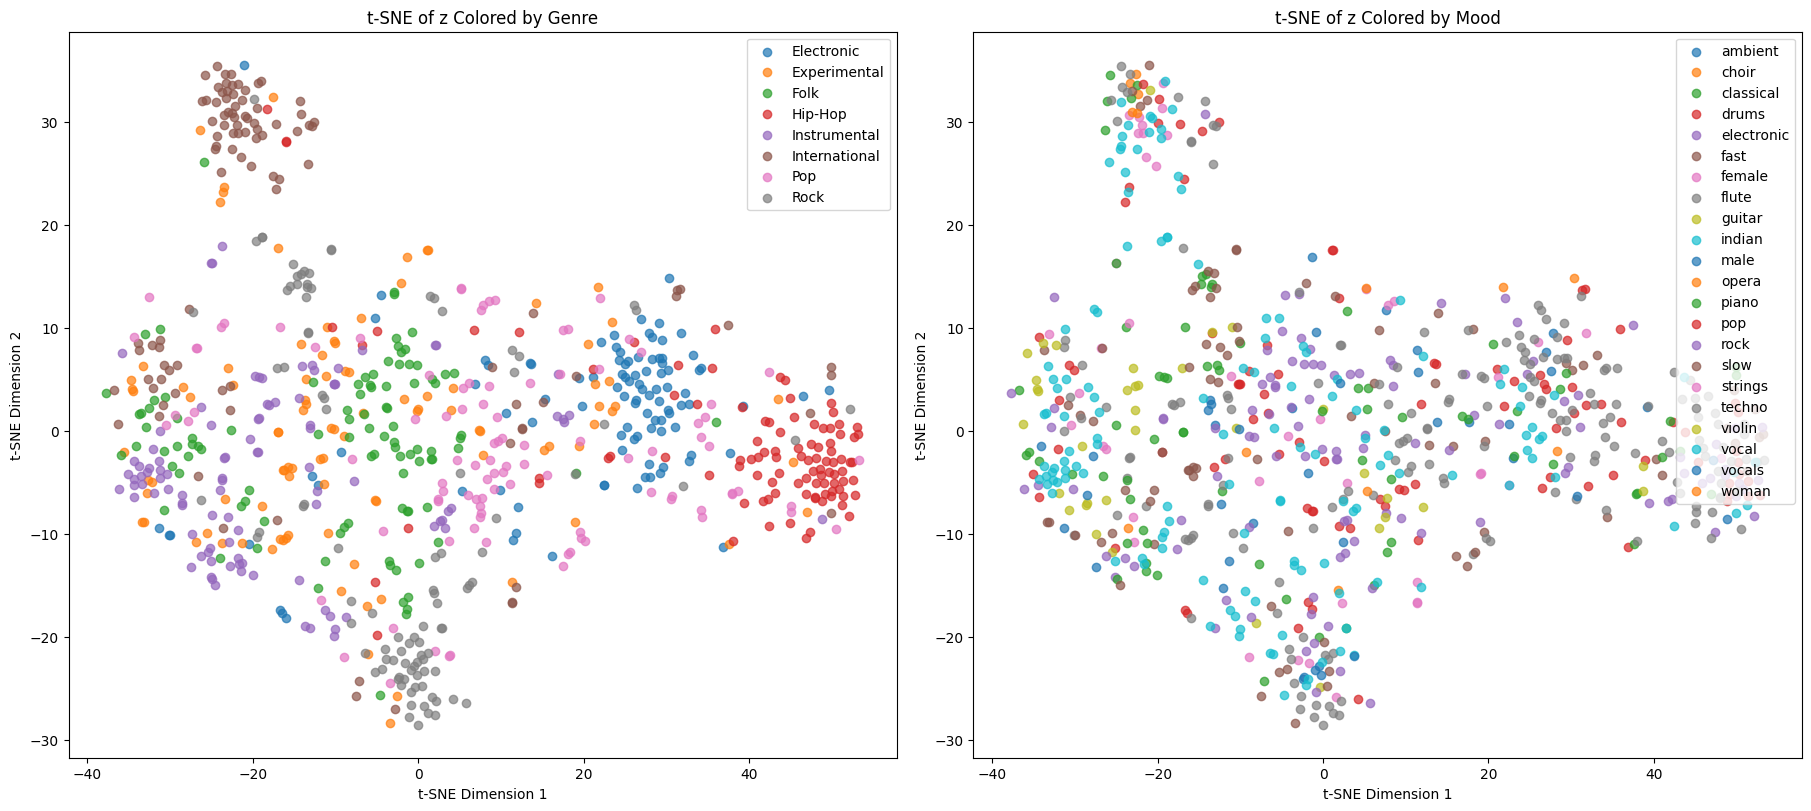

In [60]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Get fusion representation z from the final fusion model
with torch.no_grad():
    g = cross_attn_model.gnn_proj(test_gnn_emb.to(device))
    b = cross_attn_model.bert_proj(test_bert_emb.to(device))

    combined = torch.cat([g, b], dim=1)

    g_gate = cross_attn_model.gnn_gate(combined)
    b_gate = cross_attn_model.bert_gate(combined)

    g_gated = g * g_gate
    b_gated = b * b_gate

    fused_input = torch.cat([g_gated, b_gated], dim=1)

    z = cross_attn_model.fusion(fused_input)
    z = z + (g + b) / 2.0

z_2d = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
).fit_transform(z.cpu().numpy())

# Build one dominant mood label per test track from the BERT tag scores.
if "mood_labels" not in globals():
    if "mood_probs" not in globals() or "bert_classifier" not in globals():
        raise RuntimeError(
            "Run the BERT mood-prediction cell before this visualization."
        )

    mood_probs_array = np.asarray(mood_probs)
    tag_names = pd.read_csv(
        Path("../data/processed/task1_data.csv"),
        nrows=0
    ).columns[5:].tolist()

    if len(tag_names) != mood_probs_array.shape[1]:
        id_to_label = getattr(
            getattr(bert_classifier, "config", None),
            "id2label",
            {}
        )
        tag_names = [
            str(id_to_label.get(i, f"Tag {i}"))
            for i in range(mood_probs_array.shape[1])
        ]

    mood_keywords = globals().get(
        "mood_keywords",
        [
            "happy", "joy", "sad", "melancholy", "calm", "relax",
            "energetic", "upbeat", "depress", "emotional", "slow",
            "fast", "ambient", "quiet", "soft"
        ]
    )
    mood_tag_indices = [
        i for i, tag in enumerate(tag_names)
        if any(keyword in tag.lower() for keyword in mood_keywords)
    ]

    if not mood_tag_indices:
        mood_tag_indices = list(range(len(tag_names)))
        mood_tag_names = tag_names
    else:
        mood_tag_names = [tag_names[i] for i in mood_tag_indices]

    mood_labels = np.asarray([
        mood_tag_names[i]
        for i in np.argmax(mood_probs_array[:, mood_tag_indices], axis=1)
    ])

mood_labels = np.asarray(mood_labels)
if len(mood_labels) != len(z_2d):
    raise ValueError(
        f"Expected {len(z_2d)} mood labels, got {len(mood_labels)}."
    )

fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# t-SNE colored by genre
for genre_id, genre_name in enumerate(genres):
    mask = test_true == genre_id
    axes[0].scatter(
        z_2d[mask, 0],
        z_2d[mask, 1],
        label=genre_name,
        alpha=0.7
    )

axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].set_title("t-SNE of z Colored by Genre")
axes[0].legend()

# t-SNE colored by mood
for mood in np.unique(mood_labels):
    mask = mood_labels == mood
    axes[1].scatter(
        z_2d[mask, 0],
        z_2d[mask, 1],
        label=str(mood),
        alpha=0.7
    )

axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].set_title("t-SNE of z Colored by Mood")
axes[1].legend()

plt.show()

In [61]:
# Select 3 representative test tracks for qualitative case studies

case_study_indices = [0, 1, 2]

for idx in case_study_indices:
    print(
        f"Case Study {idx + 1}: "
        f"test sample index = {idx}, "
        f"genre = {genres[int(test_true[idx])]}"
    )

Case Study 1: test sample index = 0, genre = Rock
Case Study 2: test sample index = 1, genre = International
Case Study 3: test sample index = 2, genre = International


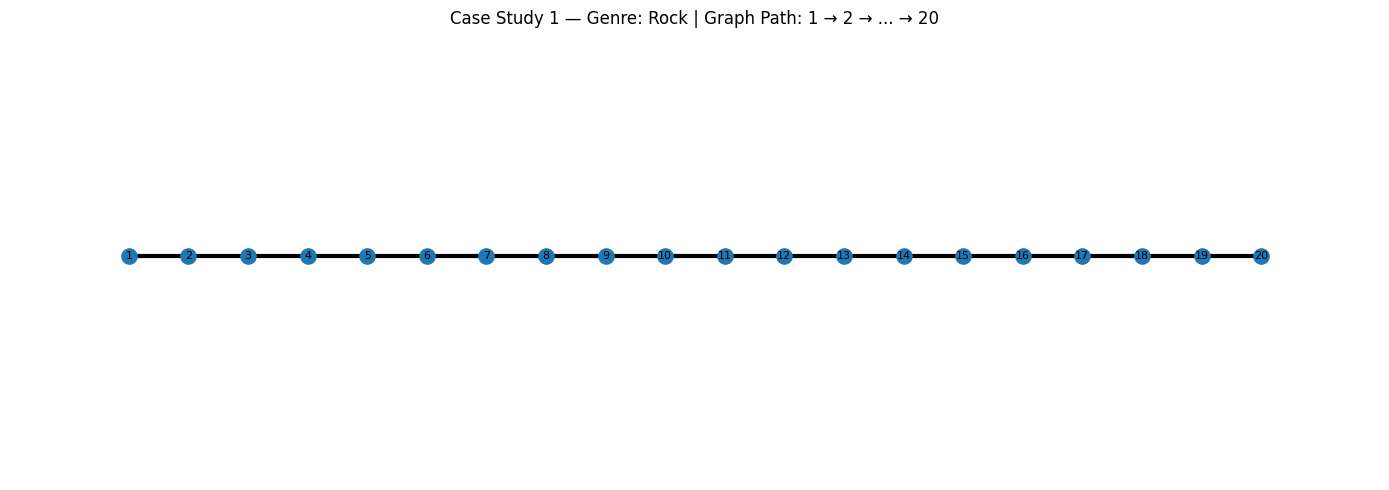

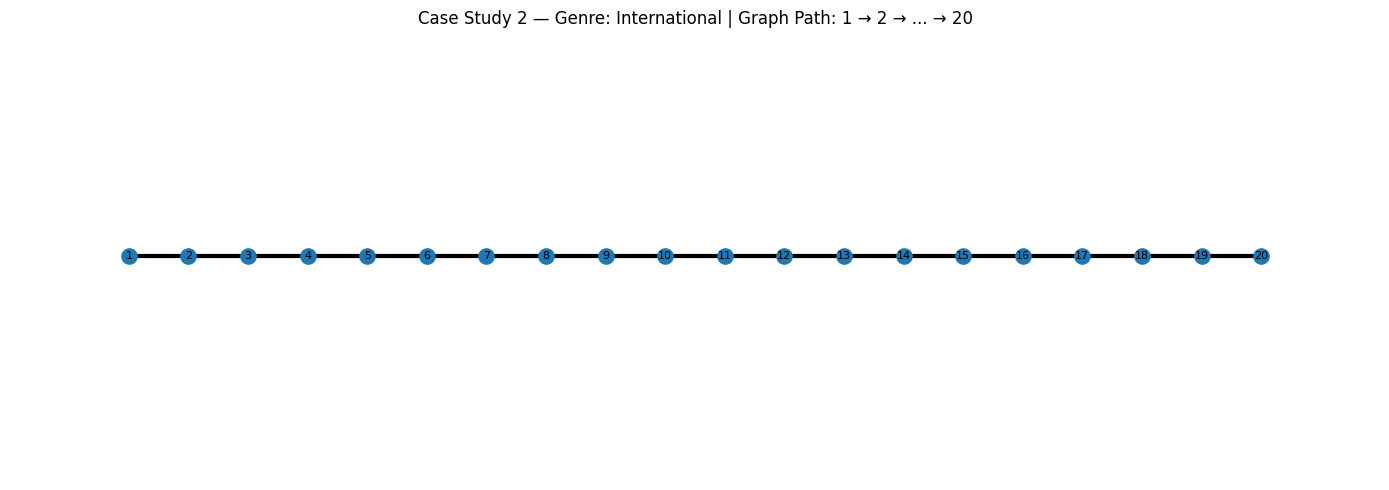

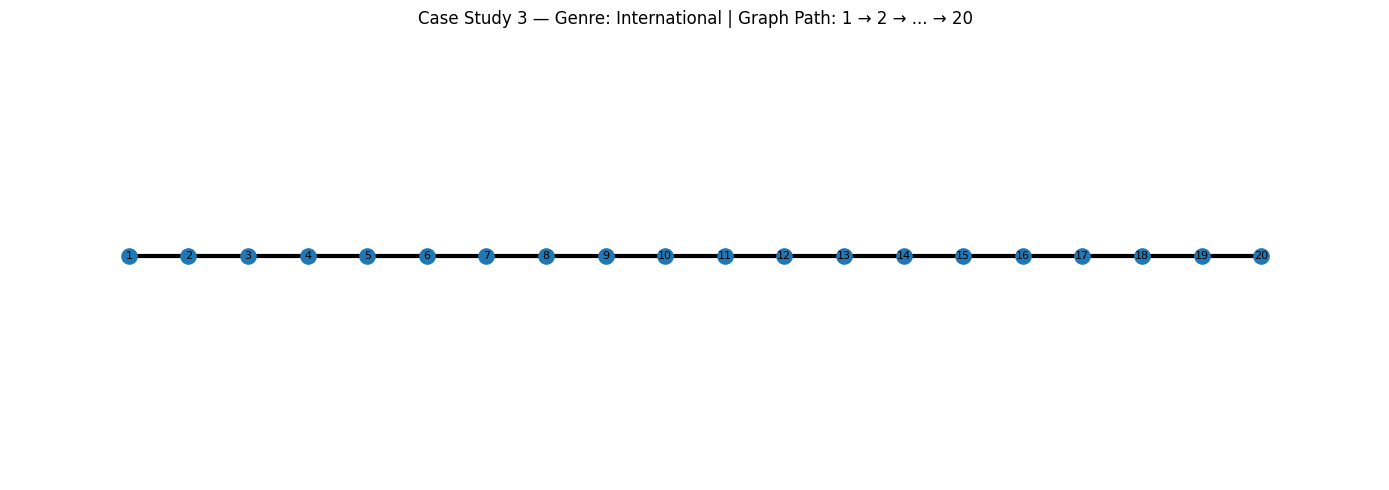

In [62]:
# Visualize graph paths for the 3 case studies

import networkx as nx
import matplotlib.pyplot as plt

for case_num, idx in enumerate(case_study_indices, start=1):

    graph = test_graphs[idx]

    G = nx.Graph()

    # Add nodes
    num_nodes = graph.x.shape[0]
    G.add_nodes_from(range(num_nodes))

    # Add edges
    edges = graph.edge_index.cpu().numpy().T
    for u, v in edges:
        G.add_edge(int(u), int(v))

    # Use the shortest temporal path through the music structure
    path = list(range(num_nodes))

    plt.figure(figsize=(14, 5))

    pos = {i: (i, 0) for i in range(num_nodes)}

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=120
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.35
    )

    # Highlight the temporal path
    if len(path) > 1:
        path_edges = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            width=3
        )

    nx.draw_networkx_labels(
        G,
        pos,
        labels={i: str(i + 1) for i in range(num_nodes)},
        font_size=8
    )

    genre_name = genres[int(test_true[idx])]

    plt.title(
        f"Case Study {case_num} — "
        f"Genre: {genre_name} | "
        f"Graph Path: 1 → 2 → ... → {num_nodes}"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [63]:
# Case-study summary: graph + text + predicted mood

for case_num, idx in enumerate(case_study_indices, start=1):

    graph = test_graphs[idx]
    genre_name = genres[int(test_true[idx])]
    text = test_texts[idx]
    mood = mood_labels[idx]

    print("=" * 80)
    print(f"CASE STUDY {case_num}")
    print("=" * 80)

    print(f"Genre:          {genre_name}")
    print(f"Predicted mood: {mood}")
    print(f"Text:           {text}")
    print(f"Graph nodes:    {graph.x.shape[0]}")
    print(f"Graph edges:    {graph.edge_index.shape[1]}")
    
    print("\nTemporal graph path:")
    print(" → ".join(str(i + 1) for i in range(graph.x.shape[0])))

    print("\nFusion model:")
    print("GNN structural embedding + BERT semantic embedding")

CASE STUDY 1
Genre:          Rock
Predicted mood: piano
Text:           Jules Lost His Jewels Ariel Pink's Haunted Graffiti Worn Copy
Graph nodes:    20
Graph edges:    158

Temporal graph path:
1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14 → 15 → 16 → 17 → 18 → 19 → 20

Fusion model:
GNN structural embedding + BERT semantic embedding
CASE STUDY 2
Genre:          International
Predicted mood: female
Text:           Mano De Dios Fósforo Macondo
Graph nodes:    20
Graph edges:    158

Temporal graph path:
1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14 → 15 → 16 → 17 → 18 → 19 → 20

Fusion model:
GNN structural embedding + BERT semantic embedding
CASE STUDY 3
Genre:          International
Predicted mood: vocal
Text:           Tio Cocodrilo Fósforo Macondo
Graph nodes:    20
Graph edges:    158

Temporal graph path:
1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14 → 15 → 16 → 17 → 18 → 19 → 20

Fusion model:
GNN structural embedding + BERT semantic embedd

In [64]:
# Show the top predicted Task 1 BERT tags for the 3 case studies

for case_num, idx in enumerate(case_study_indices, start=1):

    scores = mood_probs[idx]

    top_indices = np.argsort(scores)[::-1][:10]

    print("=" * 80)
    print(f"CASE STUDY {case_num}")
    print("=" * 80)

    for rank, tag_idx in enumerate(top_indices, start=1):
        print(
            f"{rank:2d}. {tag_names[tag_idx]:20s} "
            f"{scores[tag_idx]:.3f}"
        )

CASE STUDY 1
 1. piano                0.195
 2. electronic           0.116
 3. synth                0.099
 4. slow                 0.093
 5. ambient              0.082
 6. techno               0.066
 7. no vocal             0.056
 8. no vocals            0.053
 9. fast                 0.047
10. quiet                0.044
CASE STUDY 2
 1. female               0.150
 2. woman                0.115
 3. vocal                0.099
 4. classical            0.072
 5. flute                0.069
 6. opera                0.058
 7. slow                 0.054
 8. singing              0.043
 9. female vocal         0.041
10. female voice         0.038
CASE STUDY 3
 1. vocal                0.178
 2. vocals               0.116
 3. singing              0.088
 4. techno               0.070
 5. female               0.063
 6. voice                0.052
 7. male                 0.048
 8. woman                0.043
 9. electronic           0.039
10. fast                 0.033


In [65]:
# Find actual mood-related tags among the 50 Task-1 labels

mood_keywords = [
    "happy", "sad", "calm", "relax", "relaxed",
    "energetic", "energy", "angry", "romantic",
    "melancholy", "melancholic", "joy", "cheerful",
    "peaceful", "uplifting", "mellow", "dreamy",
    "emotional", "dark", "depress", "hopeful"
]

mood_tags = [
    tag for tag in tag_names
    if any(keyword in tag.lower() for keyword in mood_keywords)
]

print("Actual mood-related Task-1 tags:")
print(mood_tags)

Actual mood-related Task-1 tags:
[]


In [67]:
# Load full MagnaTagATune annotations and find mood tags

annotations = pd.read_csv(
    "../data/magnatagatune/annotations_final.csv",
    sep="\t"
)

all_tags = [c for c in annotations.columns if c != "clip_id"]

mood_tags_all = [
    tag for tag in all_tags
    if any(
        keyword in tag.lower()
        for keyword in [
            "happy", "sad", "calm", "relax", "energetic",
            "angry", "romantic", "melancholy", "joy",
            "cheerful", "peaceful", "uplifting", "mellow",
            "dreamy", "emotional", "dark", "depress"
        ]
    )
]

print("Mood tags in full MagnaTagATune:")
print(mood_tags_all)

Mood tags in full MagnaTagATune:
['happy', 'dark', 'mellow', 'sad', 'calm']


In [68]:
# Get actual MagnaTagATune mood labels for the 3 case studies

mood_tags = ["happy", "dark", "mellow", "sad", "calm"]

print("Mood tags:", mood_tags)
print()

for case_num, idx in enumerate(case_study_indices, start=1):

    track_id = int(test_fma_aligned.index[idx])

    # Find matching MagnaTagATune annotation by clip_id
    match = annotations[annotations["clip_id"] == track_id]

    print("=" * 80)
    print(f"CASE STUDY {case_num} | FMA track ID: {track_id}")
    print("=" * 80)

    if len(match) == 0:
        print("No exact MagnaTagATune match for this FMA track.")
        continue

    row = match.iloc[0]

    for mood in mood_tags:
        print(f"{mood:8s}: {int(row[mood])}")

Mood tags: ['happy', 'dark', 'mellow', 'sad', 'calm']

CASE STUDY 1 | FMA track ID: 182
No exact MagnaTagATune match for this FMA track.
CASE STUDY 2 | FMA track ID: 704
No exact MagnaTagATune match for this FMA track.
CASE STUDY 3 | FMA track ID: 705
No exact MagnaTagATune match for this FMA track.


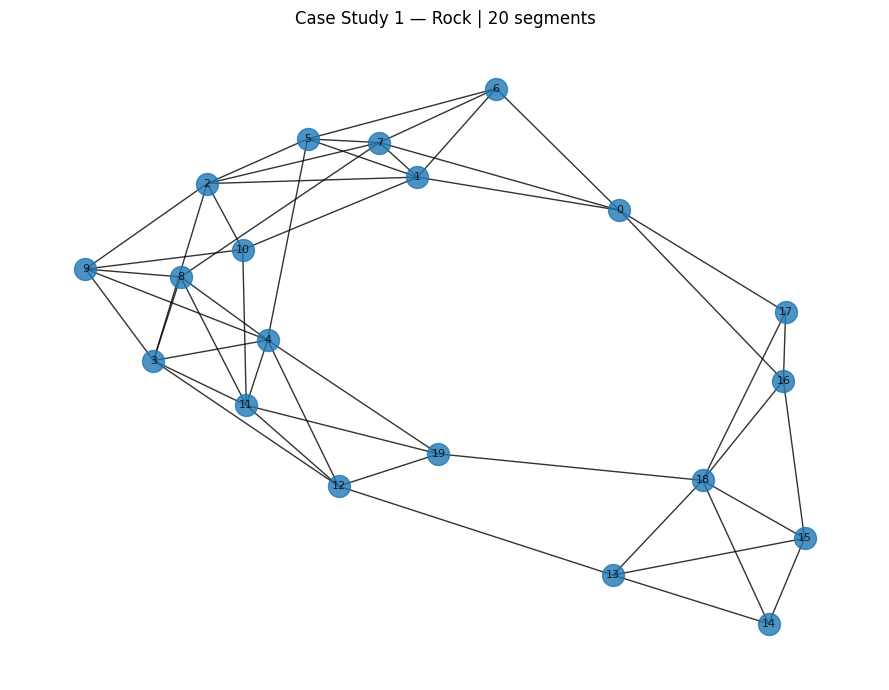

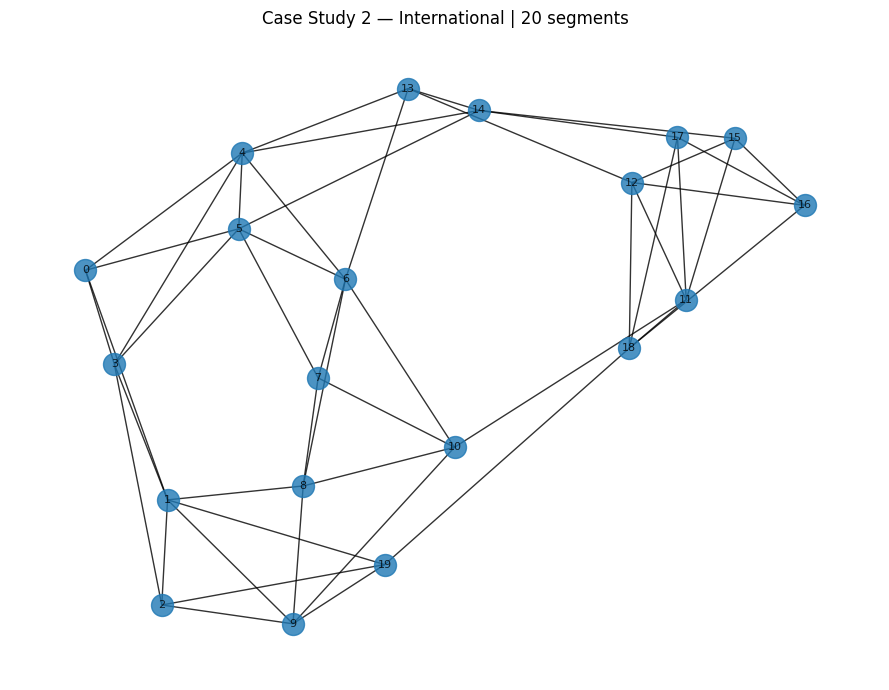

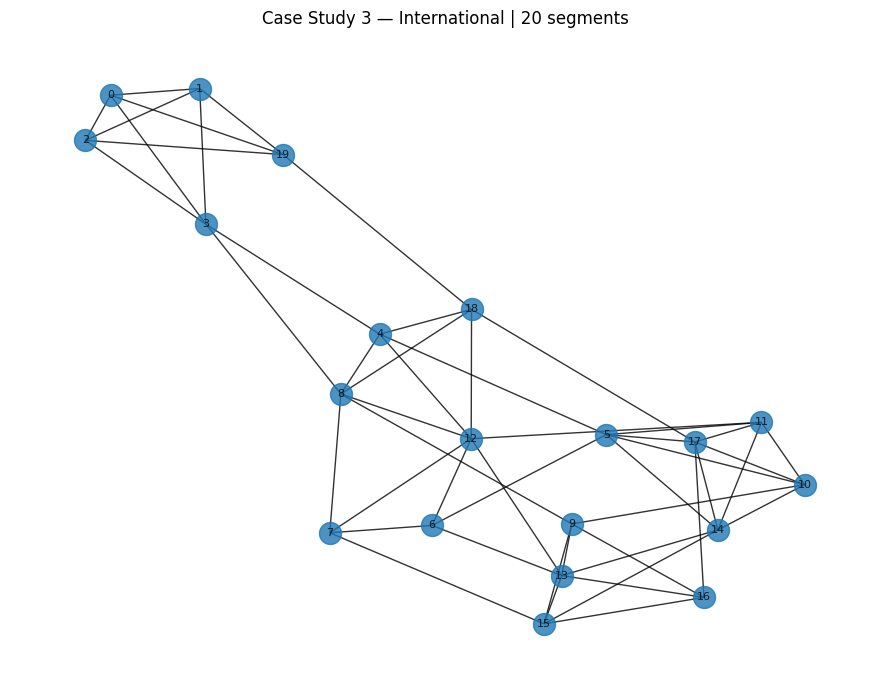

In [69]:
# Full graph visualization for the 3 case studies

import networkx as nx
import matplotlib.pyplot as plt

for case_num, idx in enumerate(case_study_indices, start=1):

    graph = test_graphs[idx]

    G = nx.Graph()

    edges = graph.edge_index.cpu().numpy().T

    # Remove duplicate edges
    for u, v in edges:
        if u != v:
            G.add_edge(int(u), int(v))

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(9, 7))

    nx.draw_networkx(
        G,
        pos,
        node_size=250,
        with_labels=True,
        font_size=8,
        alpha=0.8
    )

    genre_name = genres[int(test_true[idx])]

    plt.title(
        f"Case Study {case_num} — "
        f"{genre_name} | "
        f"{graph.x.shape[0]} segments"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [70]:
# Create a compact table for the 3 qualitative case studies

case_rows = []

for case_num, idx in enumerate(case_study_indices, start=1):

    graph = test_graphs[idx]
    genre_name = genres[int(test_true[idx])]

    case_rows.append({
        "Case Study": case_num,
        "Genre": genre_name,
        "Text Metadata": test_texts[idx],
        "Segments": graph.x.shape[0],
        "Edges": graph.edge_index.shape[1],
        "Fusion": "GNN + BERT"
    })

case_study_df = pd.DataFrame(case_rows)

display(case_study_df)

,Case Study,Genre,Text Metadata,Segments,Edges,Fusion
0,1,Rock,Jules Lost His Jewels Ariel Pink's Haunted Gra...,20,158,GNN + BERT
1,2,International,Mano De Dios Fósforo Macondo,20,158,GNN + BERT
2,3,International,Tio Cocodrilo Fósforo Macondo,20,158,GNN + BERT
